# Gradients, backward

Get d(output)/d(input) for every sample — no hand-derived formula.

**Time:** ~8 min · **Runs on:** CPU · **You need:**
[Arguments and shapes](02_arguments_and_shapes)

`hawk.diff.vjp` ("vector-Jacobian product": the Jacobian is the matrix of
every output's derivative with respect to every input; `vjp` returns that
matrix applied to a seed, without ever building it) reads a kernel's own
intermediate representation (IR) and derives a **new** IR for its
gradient — no recorded tape (a log of operations replayed backward, the
way some other autodiff systems work; hawk keeps none).

In [1]:
import hawk
from hawk import Mutable, Scalar, Vector
from hawk.math import dot


@hawk.kernel
def energy(v: Vector[3], out: Mutable[Scalar]):   # out: where the result lands
    out = 0.5 * dot(v, v)


energy


<Kernel energy slots=2>

## Deriving the backward kernel

`vjp(primal, wrt=...)` derives the backward IR for `energy`'s gradient
with respect to the names in `wrt`; `Kernel(name, ir)` names it so it
can be built like any other kernel (the optional third argument,
`planes`, declares extra planes a derived kernel never needs):

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import plot_style
plot_style()


In [3]:
from hawk import Kernel
from hawk.diff import vjp

energy_vjp = Kernel("energy_vjp", vjp(energy, wrt=("v",)))
energy_vjp

<Kernel energy_vjp slots=3>

## Running it: `bar_<name>`

A derived gradient kernel is an ordinary kernel: build it, run it.
`bar_<name>` is hawk's **adjoint** (reverse-mode derivative) naming
convention, used throughout the family: `bar_out` is the derivative *of*
the sink `out` (the seed — "how much does the loss change per unit of
`out`"; `1` for every sample means "treat `out` itself as the loss"), and
`bar_v` receives the derivative *with respect to* the input `v`.

In [4]:
import pathlib, tempfile
import numpy as np


work_dir = pathlib.Path(tempfile.mkdtemp())
hawk.build([energy, energy_vjp], work_dir, targets=("host",))

n = 4
v = np.array([[1.0, 2.0, 3.0, 4.0], [0.0, 1.0, 0.0, 1.0], [0.0, 0.0, 1.0, 1.0]])
e = np.zeros(n)
hawk.run(hawk.load(work_dir, "energy"), v=v, out=e)
print("energy:", e)


energy: [0.5 2.5 5.  9. ]


In [5]:
bar_out = np.ones(n)        # seed: d(loss)/d(energy) = 1 for every sample
bar_v = np.zeros((3, n))    # receives d(energy)/d(v)
hawk.run(hawk.load(work_dir, "energy_vjp"), v=v, bar_out=bar_out, bar_v=bar_v)
print("gradient d(energy)/dv:\n", bar_v)


gradient d(energy)/dv:
 [[1. 2. 3. 4.]
 [0. 1. 0. 1.]
 [0. 0. 1. 1.]]


Here `energy = 0.5 |v|^2`, so `d(energy)/dv = v` exactly — the printed
gradient above *is* the input.

## Checking it against finite differences

The standard sanity check for any derivative, hand-derived or not: compare
it to a central finite difference of the compiled primal kernel itself.

In [6]:
def run_energy(v):
    out = np.zeros(v.shape[1])
    hawk.run(hawk.load(work_dir, "energy"), v=v, out=out)
    return out


def run_grad(v):
    n = v.shape[1]
    bar_out, bar_v = np.ones(n), np.zeros((3, n))
    hawk.run(hawk.load(work_dir, "energy_vjp"), v=v, bar_out=bar_out, bar_v=bar_v)
    return bar_v


In [7]:
rng = np.random.default_rng(42)
n = 2000
v_batch = rng.normal(size=(3, n))
analytic = run_grad(v_batch)

h = 1e-6
numeric = np.zeros_like(v_batch)
for axis in range(3):
    plus, minus = v_batch.copy(), v_batch.copy()
    plus[axis] += h
    minus[axis] -= h
    numeric[axis] = (run_energy(plus) - run_energy(minus)) / (2 * h)

max_abs_error = np.max(np.abs(analytic - numeric))
msg = f"{n} samples x 3 components, max|analytic - central diff| = {max_abs_error:.3e}"
print(msg)

2000 samples x 3 components, max|analytic - central diff| = 9.426e-10


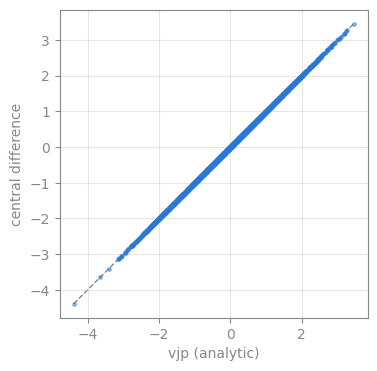

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
lo, hi = analytic.min(), analytic.max()
ax.plot([lo, hi], [lo, hi], color="#898781", lw=1, ls="--", zorder=1)
ax.scatter(analytic.ravel(), numeric.ravel(), s=6, color="#2a78d6", alpha=0.5, zorder=2)
ax.set_xlabel("vjp (analytic)"); ax.set_ylabel("central difference")
ax.set_aspect("equal"); ax.grid(alpha=0.4)
plt.show()

## What just happened

- `hawk.diff.vjp(primal, wrt=...)` derives a backward kernel from the
  primal's own IR — no recorded tape, no hand-written formula.
- `bar_out` seeds the adjoint *of* a sink; `bar_v` receives the adjoint
  *with respect to* an input — the `bar_<name>` convention hawk uses
  everywhere.
- A derived gradient is an ordinary kernel: build it, run it, and check it
  against a central finite difference of the compiled primal, the same way
  you would check a hand derivation.

## Try this

Change the seed `bar_out = np.ones(n)` to `bar_out = np.full(n, 2.0)` and
re-run: every gradient doubles, since `vjp` is linear in its seed.

## Next

[Gradients, forward](05_gradients_forward) — push a direction *through*
the same kernel instead, and see which kernels autodiff refuses to
differentiate at all.